# **Financial Forecasting Model**

This model predicts the profit of a startup based on its spending in
R&D, Administration, and Marketing.

It helps businesses estimate future profits and make better financial decisions.





## Problem Statement

Startups invest money in different areas such as:
- Research and Development
- Administration
- Marketing

The goal of this model is to predict:
- The expected profit based on these expenses.

This is a regression problem because the output is a continuous value (profit).


## Algorithm Used: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

Advantages:
- Handles complex relationships between variables
- Reduces overfitting
- Provides higher prediction accuracy

The final prediction is the average output of all decision trees.


## Load Dataset

We use the 50 Startups dataset.
It contains financial data of startups and their profits.


In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Information


In [3]:
df = pd.read_csv("50_Startups_dataset.csv")
df.head()


,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50 non-null     int64  
 1   R&D Spend        50 non-null     float64
 2   Administration   50 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            50 non-null     object 
 5   Profit           50 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 2.5+ KB


## Data Preprocessing

The dataset contains a categorical column:
- State

We convert it into numerical values using Label Encoding.


In [5]:
label_encoder = LabelEncoder()
df["State"] = label_encoder.fit_transform(df["State"])


## Feature and Target Split

Features:
- R&D Spend
- Administration
- Marketing Spend
- State

Target:
- Profit


In [6]:
X = df.drop("Profit", axis=1)
y = df["Profit"]


## Train-Test Split

We divide the dataset into:
- 80% training data
- 20% testing data


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 40
Testing samples: 10


## Model Training using Random Forest Regressor


In [8]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

## Model Prediction


In [9]:
y_pred = model.predict(X_test)


## Model Evaluation

We evaluate the model using:
- R² Score
- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)


In [10]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)


R² Score: 0.9781041171072684
Mean Squared Error: 17731112.413123153
Mean Absolute Error: 3063.0070899999882


## Actual vs Predicted Profit

This graph compares the actual profit values with the predicted profit values.
If the model performs well, the points will be close to a straight line,
indicating accurate predictions.


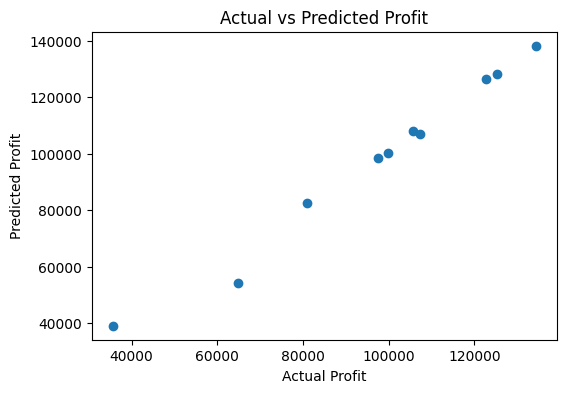

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")
plt.show()


## Save Trained Model

We save the trained model as a .pkl file.
This file will be used in the backend of the dashboard.


In [12]:
with open("financial_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved as financial_model.pkl")


Model saved as financial_model.pkl
